In [2]:
from collections import Counter
from pathlib import Path
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image
from tqdm.notebook import tqdm

# 1. Dataset Path

In [3]:
DATASET_DIR = Path("/workspace/data/raw/denomination/Bangladeshi_Paper_Currency_Raw")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

print(f"Dataset Path: {DATASET_DIR}")
print(f"Exists: {DATASET_DIR.exists()}")

Dataset Path: /workspace/data/raw/denomination/Bangladeshi_Paper_Currency_Raw
Exists: True


# 2. Dataset Structure Inspection

In [4]:
for class_dir in sorted(DATASET_DIR.iterdir()):

    if not class_dir.is_dir():
        continue

    image_count = sum(
        1
        for file_path in class_dir.iterdir()
        if file_path.suffix.lower() in IMAGE_EXTENSIONS
    )

    print(f"{class_dir.name}: {image_count} images")

10: 419 images
100: 565 images
1000: 422 images
2: 445 images
20: 480 images
200: 423 images
5: 660 images
50: 416 images
500: 1243 images


# 3. Metadata Construction

In [5]:
records: list[dict[str, object]] = []

for class_dir in sorted(DATASET_DIR.iterdir()):

    if not class_dir.is_dir():
        continue

    folder_name = class_dir.name

    denomination = folder_name.split()[0]
    authenticity = folder_name.split()[-1]

    for image_path in sorted(class_dir.iterdir()):

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        records.append(
            {
                "image_path": image_path,
                "folder": folder_name,
                "denomination": denomination,
                "authenticity": authenticity,
            }
        )

df = pd.DataFrame(records)

print(f"Total Images: {len(df)}")

df.head()

Total Images: 5073


,image_path,folder,denomination,authenticity
0,/workspace/data/raw/denomination/Bangladeshi_P...,10,10,10
1,/workspace/data/raw/denomination/Bangladeshi_P...,10,10,10
2,/workspace/data/raw/denomination/Bangladeshi_P...,10,10,10
3,/workspace/data/raw/denomination/Bangladeshi_P...,10,10,10
4,/workspace/data/raw/denomination/Bangladeshi_P...,10,10,10


# 4. Dataset Overview

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5073 entries, 0 to 5072
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   image_path    5073 non-null   object
 1   folder        5073 non-null   str   
 2   denomination  5073 non-null   str   
 3   authenticity  5073 non-null   str   
dtypes: object(1), str(3)
memory usage: 194.2+ KB


In [7]:
df.head()

,image_path,folder,denomination,authenticity
0,/workspace/data/raw/denomination/Bangladeshi_P...,10,10,10
1,/workspace/data/raw/denomination/Bangladeshi_P...,10,10,10
2,/workspace/data/raw/denomination/Bangladeshi_P...,10,10,10
3,/workspace/data/raw/denomination/Bangladeshi_P...,10,10,10
4,/workspace/data/raw/denomination/Bangladeshi_P...,10,10,10


In [8]:
df.tail()

,image_path,folder,denomination,authenticity
5068,/workspace/data/raw/denomination/Bangladeshi_P...,500,500,500
5069,/workspace/data/raw/denomination/Bangladeshi_P...,500,500,500
5070,/workspace/data/raw/denomination/Bangladeshi_P...,500,500,500
5071,/workspace/data/raw/denomination/Bangladeshi_P...,500,500,500
5072,/workspace/data/raw/denomination/Bangladeshi_P...,500,500,500


In [9]:
df.isnull().sum()

image_path      0
folder          0
denomination    0
authenticity    0
dtype: int64

In [10]:
print(f"Unique folders        : {df['folder'].nunique()}")
print(f"Unique denominations  : {df['denomination'].nunique()}")
print(f"Unique authenticity   : {df['authenticity'].nunique()}")

Unique folders        : 9
Unique denominations  : 9
Unique authenticity   : 9


In [11]:
authenticity_counts = (
    df["authenticity"]
    .value_counts()
    .sort_index()
)

authenticity_counts

authenticity
10       419
100      565
1000     422
2        445
20       480
200      423
5        660
50       416
500     1243
Name: count, dtype: int64

# 5. Authenticity 

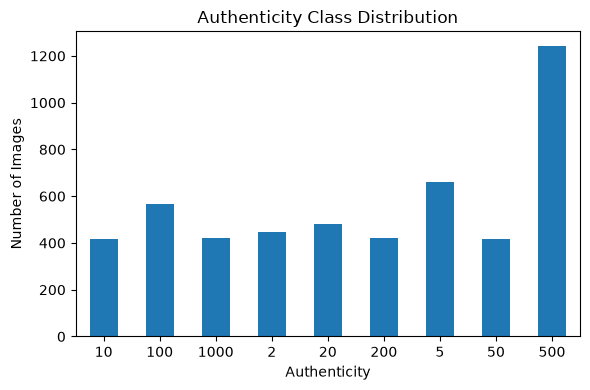

In [12]:
plt.figure(figsize=(6, 4))

authenticity_counts.plot(
    kind="bar",
    rot=0,
)

plt.title("Authenticity Class Distribution")
plt.xlabel("Authenticity")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

# 6. Denomination Distribution

In [13]:
denomination_counts = (
    df["denomination"]
    .value_counts()
    .sort_index()
)

denomination_counts

denomination
10       419
100      565
1000     422
2        445
20       480
200      423
5        660
50       416
500     1243
Name: count, dtype: int64

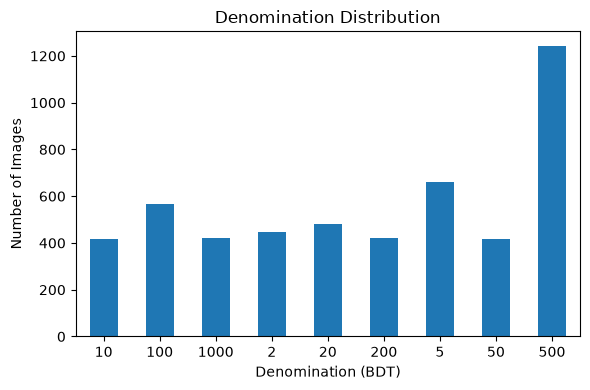

In [14]:
plt.figure(figsize=(6, 4))

denomination_counts.plot(
    kind="bar",
    rot=0,
)

plt.title("Denomination Distribution")
plt.xlabel("Denomination (BDT)")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

# 7. Authenticity x Denomination

In [15]:
cross_table = pd.crosstab(
    index=df["denomination"],
    columns=df["authenticity"],
)

cross_table

authenticity,10,100,1000,2,20,200,5,50,500
denomination,,,,,,,,,
10,419,0,0,0,0,0,0,0,0
100,0,565,0,0,0,0,0,0,0
1000,0,0,422,0,0,0,0,0,0
2,0,0,0,445,0,0,0,0,0
20,0,0,0,0,480,0,0,0,0
200,0,0,0,0,0,423,0,0,0
5,0,0,0,0,0,0,660,0,0
50,0,0,0,0,0,0,0,416,0
500,0,0,0,0,0,0,0,0,1243


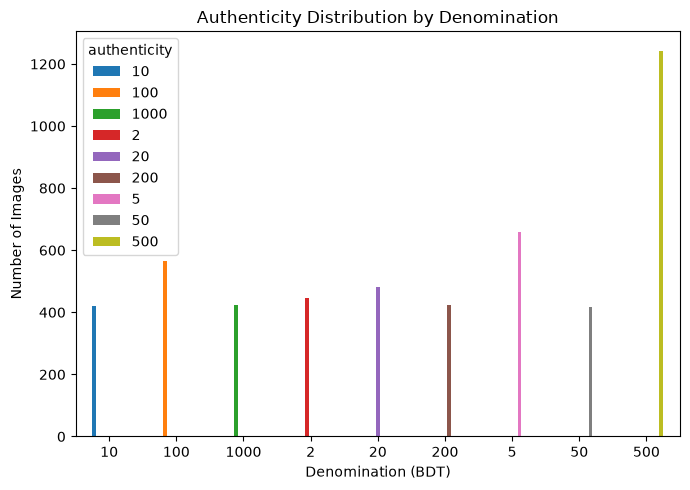

In [16]:
cross_table.plot(
    kind="bar",
    figsize=(7, 5),
)

plt.title("Authenticity Distribution by Denomination")
plt.xlabel("Denomination (BDT)")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 8. Image Dimension Analysis

In [17]:
widths: list[int] = []
heights: list[int] = []

for image_path in tqdm(df["image_path"], desc="Reading image dimensions"):

    with Image.open(image_path) as image:
        widths.append(image.width)
        heights.append(image.height)

df["width"] = widths
df["height"] = heights

df[["width", "height"]].head()

Reading image dimensions:   0%|          | 0/5073 [00:00<?, ?it/s]

,width,height
0,1140,2448
1,2020,940
2,2260,1032
3,2272,1064
4,1916,912


In [18]:
df[["width", "height"]].describe()

,width,height
count,5073.000000,5073.000000
mean,2002.744530,1373.394244
std,853.648813,672.977877
min,424.000000,400.000000
25%,1292.000000,856.000000
50%,1872.000000,1286.000000
75%,3000.000000,1512.000000
max,3356.000000,3592.000000


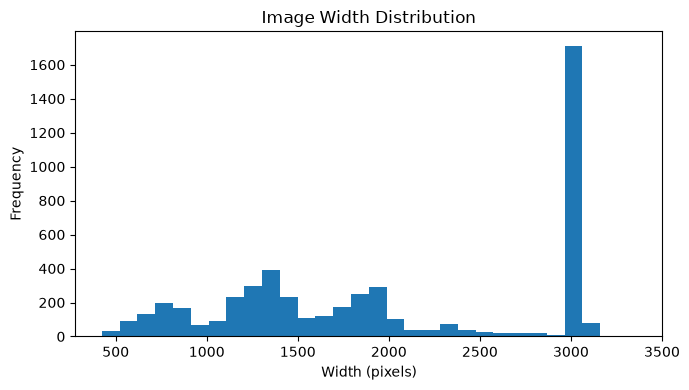

In [19]:
plt.figure(figsize=(7, 4))

plt.hist(
    df["width"],
    bins=30,
)

plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

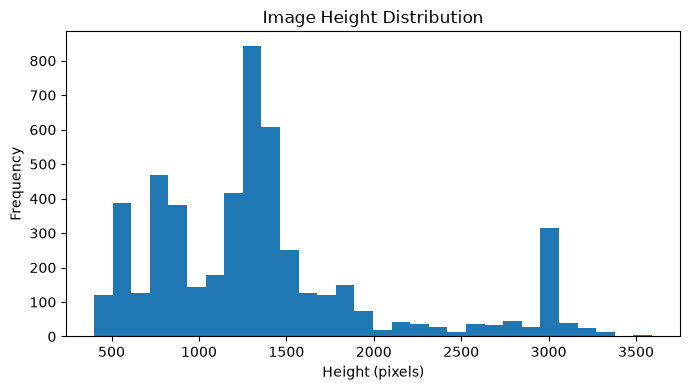

In [20]:
plt.figure(figsize=(7, 4))

plt.hist(
    df["height"],
    bins=30,
)

plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

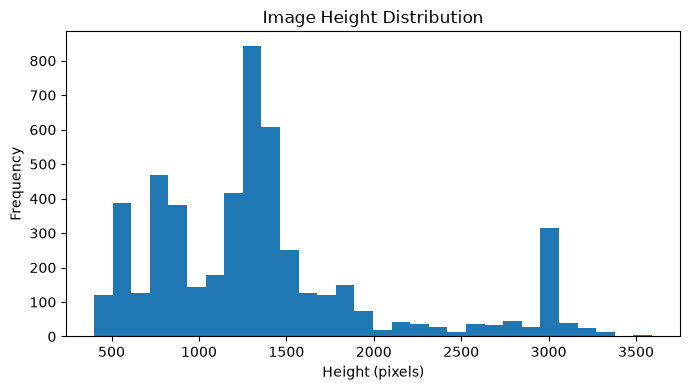

In [21]:
plt.figure(figsize=(7, 4))

plt.hist(
    df["height"],
    bins=30,
)

plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [22]:
image_sizes = (
    df[["width", "height"]]
    .value_counts()
    .reset_index(name="count")
)

image_sizes

,width,height,count
0,3000,1259,10
1,3000,1284,10
2,3000,1398,9
3,3000,1238,9
4,3000,1416,8
...,...,...,...
3792,1184,3000,1
3793,1240,2980,1
3794,1288,3144,1
3795,1476,3448,1


In [23]:
df["aspect_ratio"] = df["width"] / df["height"]

df["aspect_ratio"].describe()

count    5073.000000
mean        1.752540
std         0.799543
min         0.375000
25%         0.588816
50%         2.162942
75%         2.348000
max         2.918970
Name: aspect_ratio, dtype: float64

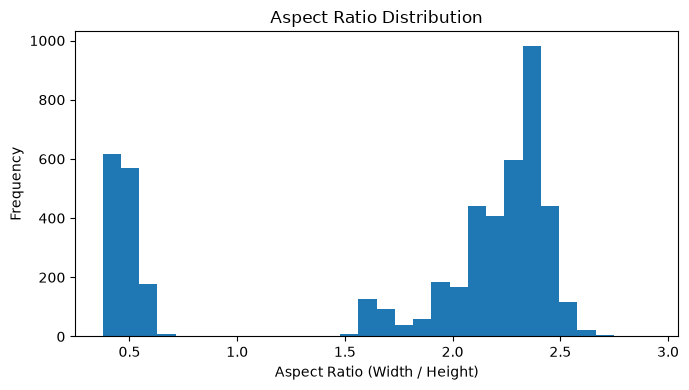

In [24]:
plt.figure(figsize=(7, 4))

plt.hist(
    df["aspect_ratio"],
    bins=30,
)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

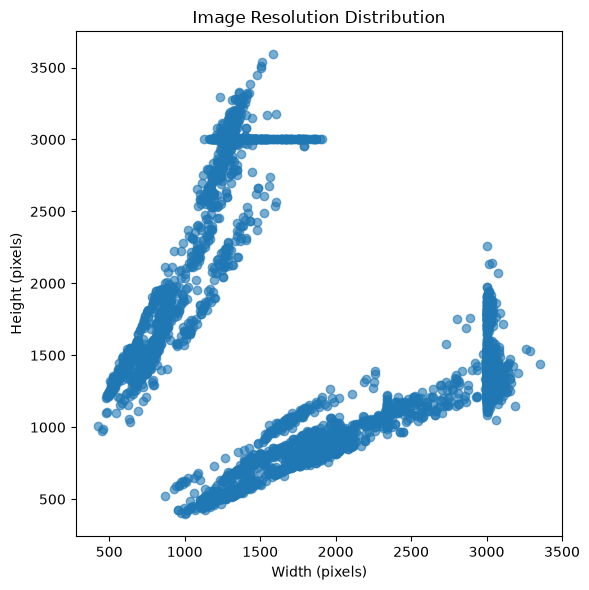

In [25]:
plt.figure(figsize=(6, 6))

plt.scatter(
    df["width"],
    df["height"],
    alpha=0.6,
)

plt.title("Image Resolution Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")

plt.tight_layout()
plt.show()

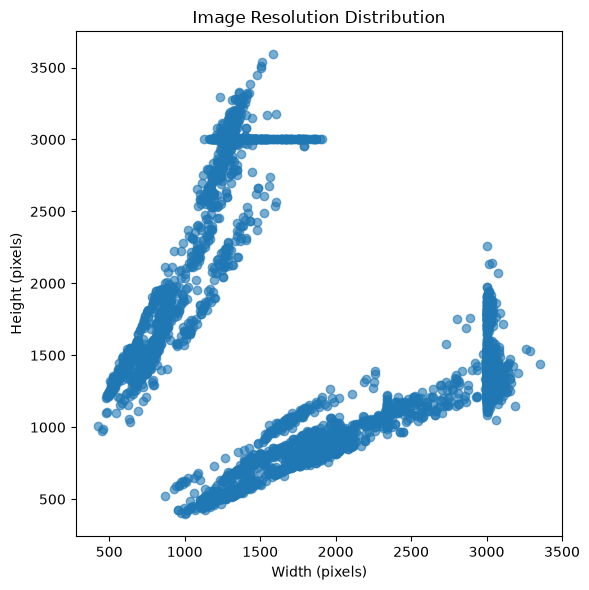

In [26]:
plt.figure(figsize=(6, 6))

plt.scatter(
    df["width"],
    df["height"],
    alpha=0.6,
)

plt.title("Image Resolution Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")

plt.tight_layout()
plt.show()

# 9. Colour Mode Analysis

In [27]:
image_modes: Counter[str] = Counter()

for image_path in tqdm(df["image_path"], desc="Checking image modes"):

    with Image.open(image_path) as image:
        image_modes[image.mode] += 1

image_modes

Checking image modes:   0%|          | 0/5073 [00:00<?, ?it/s]

Counter({'RGB': 5073})

# 10. Random Sample Visualization

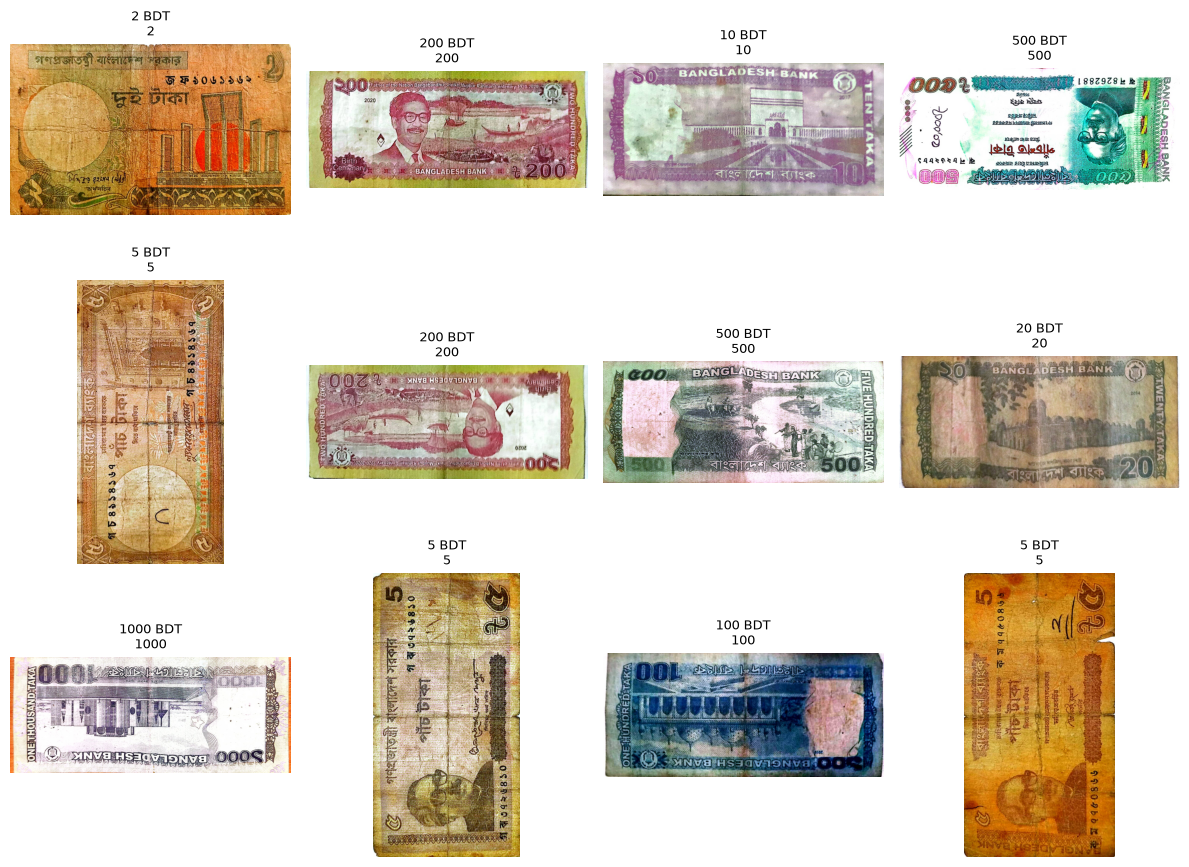

In [28]:
sample_df = df.sample(
    n=12,
    random_state=42,
)

plt.figure(figsize=(12, 9))

for index, (_, row) in enumerate(sample_df.iterrows(), start=1):

    with Image.open(row["image_path"]) as image:

        plt.subplot(3, 4, index)
        plt.imshow(image)

    plt.title(
        f'{row["denomination"]} BDT\n{row["authenticity"]}',
        fontsize=9,
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# 11. Corrupted image Detection

In [29]:
corrupted_images: list[Path] = []

for image_path in tqdm(df["image_path"], desc="Checking corrupted images"):

    try:
        with Image.open(image_path) as image:
            image.verify()

    except Exception:
        corrupted_images.append(image_path)

print(f"Corrupted Images: {len(corrupted_images)}")

Checking corrupted images:   0%|          | 0/5073 [00:00<?, ?it/s]

Corrupted Images: 0


# 12. Dataset Mean & Standard Deviation

In [30]:
channel_means: list[np.ndarray] = []
channel_stds: list[np.ndarray] = []

for image_path in tqdm(df["image_path"], desc="Computing dataset statistics"):

    image = cv2.imread(str(image_path))

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = image.astype(np.float32) / 255.0

    channel_means.append(image.mean(axis=(0, 1)))
    channel_stds.append(image.std(axis=(0, 1)))

dataset_mean = np.mean(channel_means, axis=0)
dataset_std = np.mean(channel_stds, axis=0)

print("Dataset Mean:", dataset_mean)
print("Dataset Std :", dataset_std)

Computing dataset statistics:   0%|          | 0/5073 [00:00<?, ?it/s]

KeyboardInterrupt: 

# 13. Summary Statistics

In [31]:
summary = {
    "Total Images": len(df),
    "Authenticity Classes": df["authenticity"].nunique(),
    "Denomination Classes": df["denomination"].nunique(),
    "Image Width (Mean)": round(df["width"].mean(), 2),
    "Image Height (Mean)": round(df["height"].mean(), 2),
    "Average Aspect Ratio": round(df["aspect_ratio"].mean(), 3),
    "Corrupted Images": len(corrupted_images),
}

pd.Series(summary)

Total Images            5073.000
Authenticity Classes       9.000
Denomination Classes       9.000
Image Width (Mean)      2002.740
Image Height (Mean)     1373.390
Average Aspect Ratio       1.753
Corrupted Images           0.000
dtype: float64

# 14. Save Metadata

In [ ]:
metadata_path = Path("/workspace/reports/authenticity_metadata.csv")

metadata_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

df.to_csv(
    metadata_path,
    index=False,
)

print(f"Metadata saved to: {metadata_path}")

Metadata saved to: /workspace/reports/authenticity_metadata.csv
